In [1]:
#import required classes and packages
import os
import cv2
import numpy as np
from keras.utils.np_utils import to_categorical
from keras.layers import  MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Convolution2D
from keras.models import Sequential, load_model, Model
import pickle
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt   

Using TensorFlow backend.
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16

In [39]:
#global variables definition
path = "Dataset"
labels = ['Body', 'Hand', 'Leg']
X = []
Y = []

In [40]:
#function to get integer class label for given body parts
def getLabel(name):
    index = -1
    for i in range(len(labels)):
        if labels[i] == name:
            index = i
            break
    return index

In [49]:
#function to read and process all images from Dataset folder
if os.path.exists("model/X.txt.npy"):
    X = np.load('model/X.txt.npy')
    Y = np.load('model/Y.txt.npy')
else:
    for root, dirs, directory in os.walk(path):#loop all images from dataset folder
        for j in range(len(directory)):        
                name = os.path.basename(root)
                if 'Thumbs.db' not in directory[j]:
                    img = cv2.imread(root+"/"+directory[j])#read image
                    img = cv2.resize(img, (32, 32)) #resize image
                    X.append(img)#add image features to X training array
                    label = getLabel(name)#get label for given image name
                    Y.append(label)#add label to Y array
    X = np.asarray(X)
    Y = np.asarray(Y)
    np.save('model/X.txt',X)
    np.save('model/Y.txt',Y)
print("Dataset Loading Completed")
print("Total images found in Dataset : "+str(X.shape[0]))
print("Class labels found in Dataset : "+str(labels))
print("Features contains in each image = "+str(X.shape[1] * X.shape[2] * X.shape[3]))

Dataset Loading Completed
Total images found in Dataset : 328
Class labels found in Dataset : ['Body', 'Hand', 'Leg']
Features contains in each image = 3072


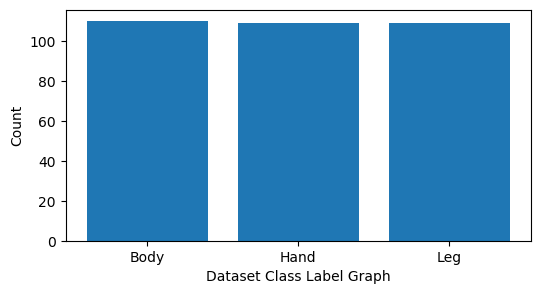

In [50]:
#visualizing class labels count found in dataset
names, count = np.unique(Y, return_counts = True)
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.figure(figsize = (6, 3)) 
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Dataset Class Label Graph")
plt.ylabel("Count")
plt.show()

In [51]:
#preprocess images like shuffling and normalization
X = X.astype('float32')
X = X/255 #normalized pixel values between 0 and 1
indices = np.arange(X.shape[0])
np.random.shuffle(indices)#shuffle all images
X = X[indices]
Y = Y[indices]
Y = to_categorical(Y)
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Dataset Image Processing & Normalization Completed")
print("80% images used to train algorithms : "+str(X_train.shape[0]))
print("20% image used to train algorithms : "+str(X_test.shape[0]))

Dataset Image Processing & Normalization Completed
80% images used to train algorithms : 262
20% image used to train algorithms : 66


In [52]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [53]:
#function to calculate accuracy and other metrics
def calculateMetrics(algorithm, predict, y_test):
    a = accuracy_score(y_test,predict)*100
    p = precision_score(y_test, predict,average='macro') * 100
    r = recall_score(y_test, predict,average='macro') * 100
    f = f1_score(y_test, predict,average='macro') * 100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  :  "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FScore    : "+str(f))    
    conf_matrix = confusion_matrix(y_test, predict) 
    plt.figure(figsize =(6, 3)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.xticks(rotation=90)
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()    

In [54]:
#defining CNN algorithm to extract features from trained dataset
cnn_model = Sequential()
#defining cnn layer with 3 X 3 matrix to filter dataset using 32 neurons
cnn_model.add(Convolution2D(32, (3 , 3), input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation = 'relu'))
#max layer to collect relevant filtered features from CNN layer 
cnn_model.add(MaxPooling2D(pool_size = (2, 2)))
#defining another layer to further filter features
cnn_model.add(Convolution2D(32, (3, 3), activation = 'relu'))
cnn_model.add(MaxPooling2D(pool_size = (2, 2)))
cnn_model.add(Flatten())
#defining output layer
cnn_model.add(Dense(units = 256, activation = 'relu'))
cnn_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
#compiling, training and loading CNN model
cnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/cnn_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn_weights.hdf5', verbose = 1, save_best_only = True)
    hist = cnn_model.fit(X, Y, batch_size = 16, epochs = 10, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/cnn_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    cnn_model.load_weights("model/cnn_weights.hdf5")
#getting trained layer from CNN model
cnn_features_model = Model(cnn_model.inputs, cnn_model.layers[-2].output)#create cnn  model
cnn_features = cnn_features_model.predict(X)  #extracting cnn features
Y = np.argmax(Y, axis=1)
print("Extracted CNN Features from each image = "+str(cnn_features.shape[1]))

Extracted CNN Features from each image = 256


SVM Algorithm Accuracy  :  98.98989898989899
SVM Algorithm Precision : 99.09909909909909
SVM Algorithm Recall    : 98.88888888888889
SVM Algorithm FScore    : 98.97840724402135


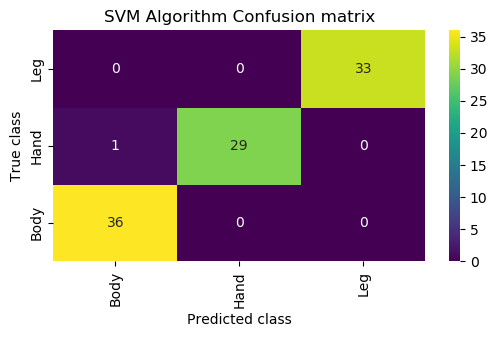

In [55]:
#training SVM algorithm on CNN extracted features
#splitting cnn features into train and test
X_train, X_test, y_train, y_test = train_test_split(cnn_features, Y, test_size=0.3) #split dataset into train and test
svm_cls = svm.SVC(C=102.0, tol=1.9)
svm_cls.fit(X_train, y_train)
#performing prediction on test data
predict = svm_cls.predict(X_test)
#call this function to evaluate algorithm performance
calculateMetrics("SVM Algorithm", predict, y_test)#calculate accuracy and other metrics

Random Forest Algorithm Accuracy  :  94.94949494949495
Random Forest Algorithm Precision : 95.0731981981982
Random Forest Algorithm Recall    : 94.93265993265993
Random Forest Algorithm FScore    : 94.89229776459118


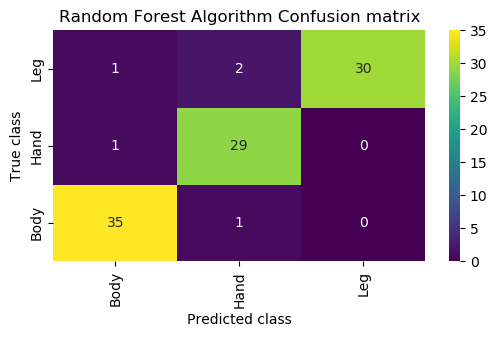

In [56]:
#training Random Forest algorithm on CNN extracted features
rf_cls = RandomForestClassifier(n_estimators=5)
rf_cls.fit(X_train, y_train)
#performing prediction on test data
predict = rf_cls.predict(X_test)
#call this function to evaluate algorithm performance
calculateMetrics("Random Forest Algorithm", predict, y_test)#calculate accuracy and other metrics

Decision Tree Algorithm Accuracy  :  90.9090909090909
Decision Tree Algorithm Precision : 90.982383084719
Decision Tree Algorithm Recall    : 90.58922558922559
Decision Tree Algorithm FScore    : 90.69797551789077


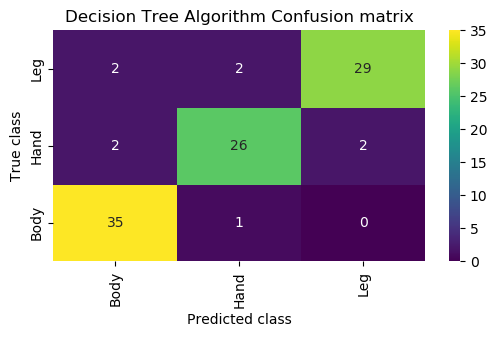

In [57]:
#training DecisionTreeClassifier algorithm on CNN extracted features
dt_cls = DecisionTreeClassifier()
dt_cls.fit(X_train, y_train)
#performing prediction on test data
predict = dt_cls.predict(X_test)
#call this function to evaluate algorithm performance
calculateMetrics("Decision Tree Algorithm", predict, y_test)#calculate accuracy and other metrics

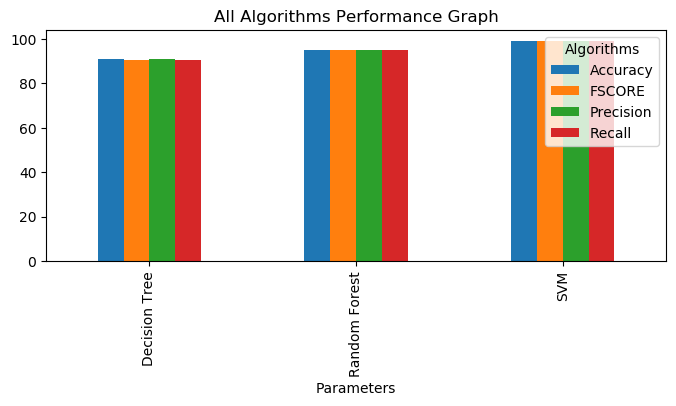

In [59]:
#plot all algorithm performance in tabukar format
import pandas as pd
df = pd.DataFrame([['SVM','Accuracy',accuracy[0]],['SVM','Precision',precision[0]],['SVM','Recall',recall[0]],['SVM','FSCORE',fscore[0]],
                   ['Random Forest','Accuracy',accuracy[1]],['Random Forest','Precision',precision[1]],['Random Forest','Recall',recall[1]],['Random Forest','FSCORE',fscore[1]],
                   ['Decision Tree','Accuracy',accuracy[2]],['Decision Tree','Precision',precision[2]],['Decision Tree','Recall',recall[2]],['Decision Tree','FSCORE',fscore[2]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(8, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [60]:
#display all algorithm performnace
algorithms = ['CNN Algorithm', 'Random Forest', 'Decision Tree']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,CNN Algorithm,98.989899,99.099099,98.888889,98.978407
1,Random Forest,94.949495,95.073198,94.932660,94.892298
2,Decision Tree,90.909091,90.982383,90.589226,90.697976


In [69]:
#use this function to predict human body parts presence in disaster area
def predict(image_path):
    image = cv2.imread(image_path)#read test image
    img = cv2.resize(image, (32, 32))#resize image
    im2arr = np.array(img)
    im2arr = im2arr.reshape(1,32,32,3)#convert image as 4 dimension
    img = np.asarray(im2arr)
    img = img.astype('float32')#convert image features as float
    img = img/255 #normalized image
    features = cnn_features_model.predict(img)#extract cnn features from given imagee using cnn model
    predict = svm_cls.predict(features)[0]
    img = cv2.imread(image_path)
    img = cv2.resize(img, (500,300))#display image with predicted output
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cv2.putText(img, 'Victim Part Detected : '+labels[predict], (100, 25),  cv2.FONT_HERSHEY_SIMPLEX,0.7, (0, 0, 255), 2)
    plt.imshow(img)

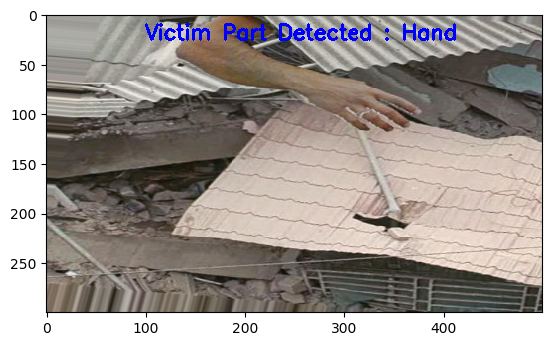

In [70]:
#call this function with test image to perform prediction
predict("testImages/0.png")

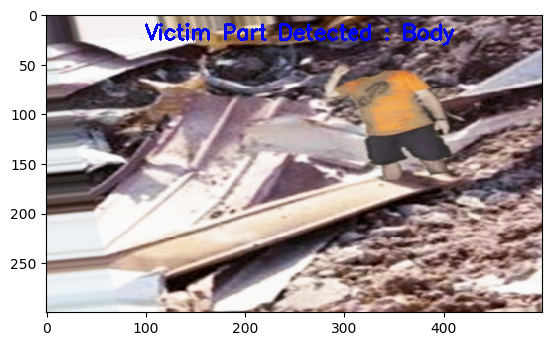

In [63]:
#call this function with test image to perform prediction
predict("testImages/1.png")

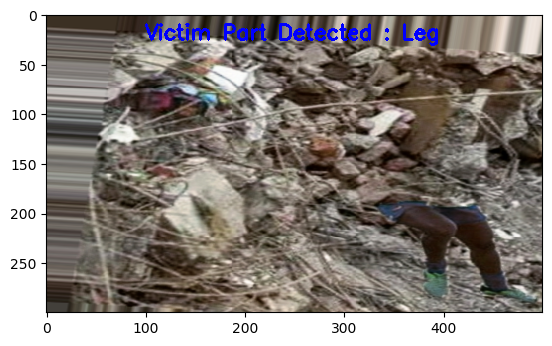

In [64]:
#call this function with test image to perform prediction
predict("testImages/2.png")